In [1]:
import sys
import os

sys.path.append(
  os.path.abspath("..")
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from engine.data import DataHandler

data_handler = DataHandler(
  "../data/market_data.csv"
)

data = data_handler.load_data()

data.head()

Market data validation successful.


,Date,Open,High,Low,Close,Volume
0,2026-01-02,100,103,99,102,100000
1,2026-01-05,102,105,101,104,120000
2,2026-01-06,104,106,102,103,110000
3,2026-01-07,103,107,102,106,130000
4,2026-01-08,106,108,104,107,125000


In [3]:
from engine.portfolio import Portfolio
from engine.execution import ExecutionEngine
from engine.backtest import BacktestEngine
from engine.position_sizing import PositionSizer
from engine.volatility import VolatilityModel
from engine.costs import TransactionCostModel
from engine.metrics import PerformanceMetrics

from strategies.moving_average import MovingAverageStrategy
from engine.benchmark import BuyAndHoldBenchmark

In [4]:
strategy = MovingAverageStrategy(
  fast_window=3,
  slow_window=5
)

portfolio = Portfolio(
  initial_capital=10000
)

cost_model = TransactionCostModel(
  commission_rate=0.001
)

execution_engine = ExecutionEngine(
  portfolio,
  cost_model
)

position_sizer = PositionSizer(
  base_allocation=0.20,
  max_allocation=0.20,
  target_volatility=0.20
)

volatility_model = VolatilityModel()

backtest = BacktestEngine(
  data=data,
  strategy=strategy,
  portfolio=portfolio,
  execution_engine=execution_engine,
  position_sizer=position_sizer,
  volatility_model=volatility_model,
  symbol="AAPL"
)

result = backtest.run()

In [5]:
benchmark = BuyAndHoldBenchmark(
  initial_capital=10000
)

prices = data["Close"].tolist()
dates = data.index.tolist()

benchmark_result = benchmark.run(
  prices,
  dates
)

In [6]:
print(
  "QuantForge Final Value:",
  result["final_value"]
)

print(
  "Buy & Hold Final Value:",
  benchmark_result["final_value"]
)

QuantForge Final Value: 9928.73186
Buy & Hold Final Value: 10490


In [7]:
strategy_history = result["portfolio_history"]
benchmark_history = benchmark_result["portfolio_history"]

strategy_dates = [
  snapshot["date"]
  for snapshot in strategy_history
]

strategy_values = [
  snapshot["portfolio_value"]
  for snapshot in strategy_history
]

benchmark_dates = [
  snapshot["date"]
  for snapshot in benchmark_history
]

benchmark_values = [
  snapshot["portfolio_value"]
  for snapshot in benchmark_history
]

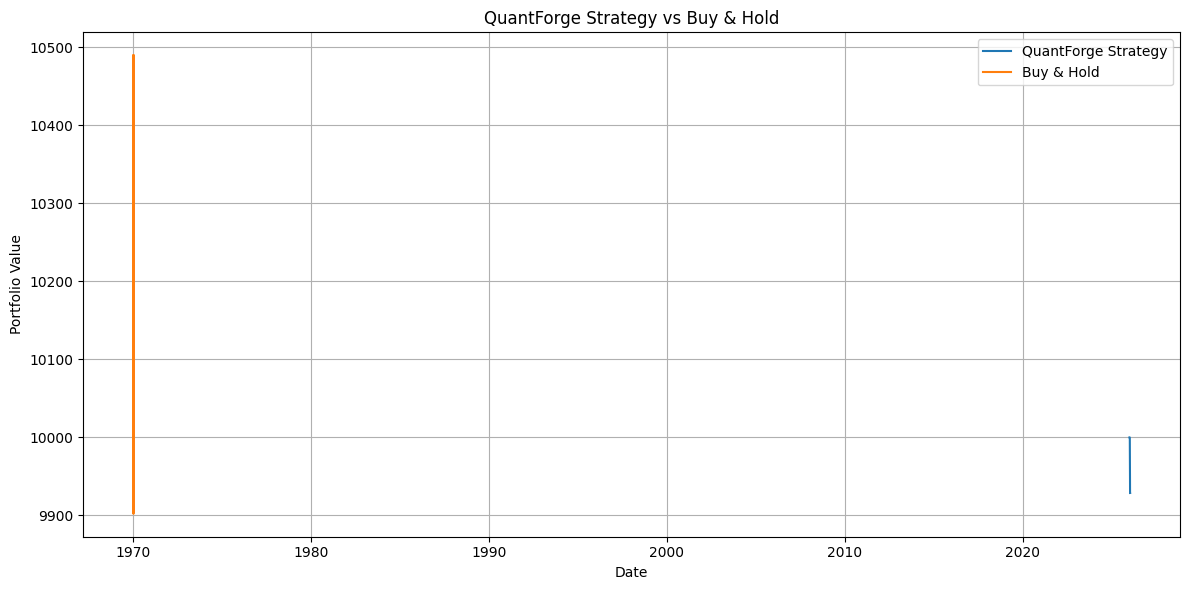

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
  strategy_dates,
  strategy_values,
  label="QuantForge Strategy"
)

plt.plot(
  benchmark_dates,
  benchmark_values,
  label="Buy & Hold"
)

plt.title(
  "QuantForge Strategy vs Buy & Hold"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [9]:
strategy_values = np.array(
  strategy_values
)

running_max = np.maximum.accumulate(
  strategy_values
)

drawdown = (
  strategy_values - running_max
) / running_max

max_drawdown = drawdown.min()

print(
  "Maximum Drawdown:",
  f"{max_drawdown:.2%}"
)

Maximum Drawdown: -0.71%


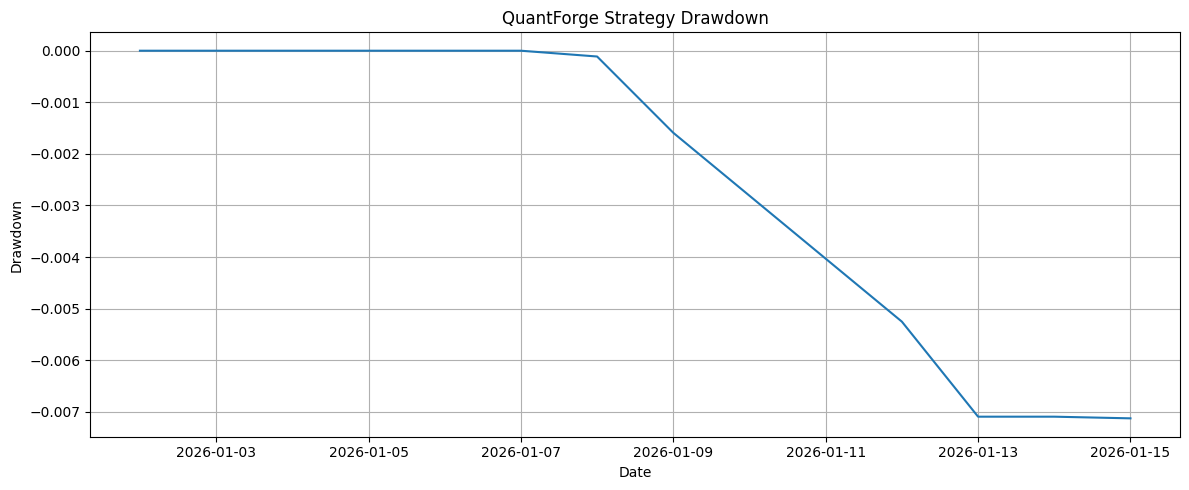

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
  strategy_dates,
  drawdown
)

plt.title(
  "QuantForge Strategy Drawdown"
)

plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.grid(True)

plt.tight_layout()

plt.show()

In [12]:
initial_capital = 10000
final_value = result["final_value"]

total_return = (
  (final_value - initial_capital)
  / initial_capital
)

max_drawdown = drawdown.min()

print("===== QUANTFORGE PERFORMANCE =====")
print(
  "Final Portfolio Value:",
  f"{final_value:.2f}"
)

print(
  "Total Return:",
  f"{total_return:.2%}"
)

print(
  "Maximum Drawdown:",
  f"{max_drawdown:.2%}"
)

print(
  "Number of Trades:",
  len(result["trade_history"])
)

print()
print("===== BUY & HOLD =====")

print(
  "Final Portfolio Value:",
  f"{benchmark_result['final_value']:.2f}"
)

print(
  "Total Return:",
  f"{benchmark_result['total_return']:.2%}"
)

===== QUANTFORGE PERFORMANCE =====
Final Portfolio Value: 9928.73
Total Return: -0.71%
Maximum Drawdown: -0.71%
Number of Trades: 5

===== BUY & HOLD =====
Final Portfolio Value: 10490.00
Total Return: 4.90%


In [13]:
strategy_return = total_return
benchmark_return = benchmark_result["total_return"]

excess_return = (
  strategy_return - benchmark_return
)

print(
  "Excess Return vs Buy & Hold:",
  f"{excess_return:.2%}"
)

Excess Return vs Buy & Hold: -5.61%
